## Config

In [142]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA

import json
import glob

from googleapiclient.discovery import build

In [120]:
df = pd.read_json("../../data/processed/ve_channels/ve_with_features.json")

In [121]:
df.head()

,channel_id,channel_name,title,description,country,topics,keywords,uploads,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,The Film Essay,A video essay channel devoted to making videos...,GB,[https://en.wikipedia.org/wiki/Television_prog...,"""film essay"" ""video essay"" ""film analysis"" ""fi...",UUqgh7QNlVV8kv3LBTJZYWrg,[{'title': 'Why Christopher Nolan uses time as...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"filmmaking ""film analysis"" ""video essay""",UUjFqcJQXGZ6T6sxyFB-5i6A,[{'title': 'Every Frame x Lackadaisy - Intervi...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,None,UUr8r7UVsDaRiIQSVUHVBd_A,"[{'title': 'Why I Went to a MENTAL HOSPITAL.',..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,[https://en.wikipedia.org/wiki/Role-playing_vi...,None,UUjKSoJlPgcK6BmoSqXpj5xQ,"[{'title': 'ACTION BUTTON PICTURES PRESENTS ""L..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"[https://en.wikipedia.org/wiki/Entertainment, ...","movies film ""video essays"" ""film essay""",UUUyvQV2JsICeLZP4c_h40kA,"[{'title': 'Why Some Movies Feel More Alive', ..."


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   title         251 non-null    object
 3   description   251 non-null    object
 4   country       198 non-null    object
 5   topics        247 non-null    object
 6   keywords      159 non-null    object
 7   uploads       251 non-null    object
 8   videos        251 non-null    object
dtypes: object(9)
memory usage: 17.8+ KB


## preprocessing

dropping duplicate channel name column and upload playlist id column

In [123]:
df = df.drop(["title", "uploads"], axis=1)
df = df.reset_index(drop=True)
df

,channel_id,channel_name,description,country,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,GB,[https://en.wikipedia.org/wiki/Television_prog...,"""film essay"" ""video essay"" ""film analysis"" ""fi...",[{'title': 'Why Christopher Nolan uses time as...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"filmmaking ""film analysis"" ""video essay""",[{'title': 'Every Frame x Lackadaisy - Intervi...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,None,"[{'title': 'Why I Went to a MENTAL HOSPITAL.',..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,[https://en.wikipedia.org/wiki/Role-playing_vi...,None,"[{'title': 'ACTION BUTTON PICTURES PRESENTS ""L..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"[https://en.wikipedia.org/wiki/Entertainment, ...","movies film ""video essays"" ""film essay""","[{'title': 'Why Some Movies Feel More Alive', ..."
...,...,...,...,...,...,...,...
246,UC3KX9qPhy89UdoXvE_EV87A,True Crime - Jack!,Welcome to the channel where real crimes come ...,US,"[https://en.wikipedia.org/wiki/Film, https://e...","""true crime"" ""crime documentary"" ""solved case""...",[{'title': 'No One Knew Her Dirtiest Secret… U...
247,UC9v4NQI8PiAsKZe5CBtgdPw,Criminal Core,If you love True Crime you are in the right pl...,ZA,"[https://en.wikipedia.org/wiki/Knowledge, http...","""cold cases"" ""cold cases solved"" ""true crime"" ...",[{'title': '5 Cold Cases With BREAKTHROUGHS In...
248,UCt_0qjzmxopG3leL3OuvlFQ,NationSquid,Computer viruses. Technology. Internet Mysteri...,US,"[https://en.wikipedia.org/wiki/Technology, htt...","""Creepypasta countdowns"" ""best creepypastas"" ""...",[{'title': 'The Mistakes That Ended Yahoo Answ...
249,UCT0dmfFCLWuVKPWZ6wcdKyg,James Jani,Hi - I'm James! \n\nThis channel explores my d...,GB,"[https://en.wikipedia.org/wiki/Society, https:...","business entrepreneurship ""how to start a busi...","[{'title': 'The Cult of the Dead Stock.', 'des..."


extracting topic names from wikipedia link

In [124]:
df["topics"] = df["topics"].apply(
    lambda cell: ", ".join(
        url.split("/")[-1].replace("_", " ") for url in cell
    ) if cell is not None else None
)

In [125]:
df.head()

,channel_id,channel_name,description,country,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,GB,"Television program, Film, Entertainment","""film essay"" ""video essay"" ""film analysis"" ""fi...",[{'title': 'Why Christopher Nolan uses time as...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,"Lifestyle (sociology), Entertainment, Film","filmmaking ""film analysis"" ""video essay""",[{'title': 'Every Frame x Lackadaisy - Intervi...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,"Lifestyle (sociology), Entertainment, Film",None,"[{'title': 'Why I Went to a MENTAL HOSPITAL.',..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,"Role-playing video game, Action-adventure game...",None,"[{'title': 'ACTION BUTTON PICTURES PRESENTS ""L..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"Entertainment, Film, Lifestyle (sociology)","movies film ""video essays"" ""film essay""","[{'title': 'Why Some Movies Feel More Alive', ..."


imputing Nones in topics and keywords with value from other column

In [126]:
df[df["topics"].isna() & df["keywords"].isna()]

,channel_id,channel_name,description,country,topics,keywords,videos
139,UCa840NC-ZxtMIZ5wYnBcn7w,Doug Woolever,,None,None,None,[{'title': 'Spongebob Squarepants: Skin Theory...


for this one i'll manually fill in topics and keywords. for others ill use one to fill the other

In [127]:
df.at[139, "country"] = "US"
df.at[139, "topics"] = "Entertainment"
df.at[139, "keywords"] = "TV analysis theory spongebob"

In [128]:
df.iloc[139]

channel_id                               UCa840NC-ZxtMIZ5wYnBcn7w
channel_name                                        Doug Woolever
description                                                      
country                                                        US
topics                                              Entertainment
keywords                             TV analysis theory spongebob
videos          [{'title': 'Spongebob Squarepants: Skin Theory...
Name: 139, dtype: object

In [129]:
df["keywords"] = df["keywords"].str.replace("\"", "", regex=False)

In [130]:
df["keywords"]

0      film essay video essay film analysis film revi...
1                   filmmaking film analysis video essay
2                                                   None
3                                                   None
4                    movies film video essays film essay
                             ...                        
246    true crime crime documentary solved case unsol...
247    cold cases cold cases solved true crime unsolv...
248    Creepypasta countdowns best creepypastas count...
249    business entrepreneurship how to start a busin...
250                                                 None
Name: keywords, Length: 251, dtype: object

In [131]:
df["topics"] = df["topics"].fillna(df["keywords"])
df["keywords"] = df["keywords"].fillna(df["topics"])

In [132]:
df.head()

,channel_id,channel_name,description,country,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,GB,"Television program, Film, Entertainment",film essay video essay film analysis film revi...,[{'title': 'Why Christopher Nolan uses time as...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,"Lifestyle (sociology), Entertainment, Film",filmmaking film analysis video essay,[{'title': 'Every Frame x Lackadaisy - Intervi...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,"Lifestyle (sociology), Entertainment, Film","Lifestyle (sociology), Entertainment, Film","[{'title': 'Why I Went to a MENTAL HOSPITAL.',..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,"Role-playing video game, Action-adventure game...","Role-playing video game, Action-adventure game...","[{'title': 'ACTION BUTTON PICTURES PRESENTS ""L..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"Entertainment, Film, Lifestyle (sociology)",movies film video essays film essay,"[{'title': 'Why Some Movies Feel More Alive', ..."


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   country       199 non-null    object
 4   topics        251 non-null    object
 5   keywords      251 non-null    object
 6   videos        251 non-null    object
dtypes: object(7)
memory usage: 13.9+ KB


flattening videos column (a list of dictionaries)

In [134]:
videos = df["videos"][0]

In [135]:
flat = [v for vid in videos for k, v in vid.items()]
" ".join(flat)

"Why Christopher Nolan uses time as architecture Christopher Nolan has become one of cinema’s most distinctive directors, known for his fragmented, non‑linear narratives and time‑bending storytelling. In this video, I break down how Nolan uses structure, parallel timelines, and temporal manipulation to create immersion, emotion, and scale across films like Inception, Memento, Interstellar, Tenet, Dunkirk, and The Prestige.\n\nFrom puzzle‑box narratives to layered timelines, Nolan turns time into a narrative engine—shaping character psychology, building tension, and transforming action into metaphor. His films challenge the audience to piece together meaning, creating a unique blend of blockbuster spectacle and art‑film experimentation. I explore how he uses structure as a sensory experience, why his stories feel so grand, and how his manipulation of time deepens themes of memory, identity, obsession, and love.\n\nWith The Odyssey on the horizon, we look at how Nolan’s signature style m

In [136]:
df.head()

,channel_id,channel_name,description,country,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,GB,"Television program, Film, Entertainment",film essay video essay film analysis film revi...,[{'title': 'Why Christopher Nolan uses time as...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,"Lifestyle (sociology), Entertainment, Film",filmmaking film analysis video essay,[{'title': 'Every Frame x Lackadaisy - Intervi...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,"Lifestyle (sociology), Entertainment, Film","Lifestyle (sociology), Entertainment, Film","[{'title': 'Why I Went to a MENTAL HOSPITAL.',..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,"Role-playing video game, Action-adventure game...","Role-playing video game, Action-adventure game...","[{'title': 'ACTION BUTTON PICTURES PRESENTS ""L..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"Entertainment, Film, Lifestyle (sociology)",movies film video essays film essay,"[{'title': 'Why Some Movies Feel More Alive', ..."


In [137]:
df["videos"] = df["videos"].apply(lambda row: " ".join([v for vids in row for k, v in vids.items()]))

In [138]:
df.head()

,channel_id,channel_name,description,country,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,GB,"Television program, Film, Entertainment",film essay video essay film analysis film revi...,Why Christopher Nolan uses time as architectur...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,"Lifestyle (sociology), Entertainment, Film",filmmaking film analysis video essay,Every Frame x Lackadaisy - Interview with Trac...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,"Lifestyle (sociology), Entertainment, Film","Lifestyle (sociology), Entertainment, Film",Why I Went to a MENTAL HOSPITAL. If you're str...
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,"Role-playing video game, Action-adventure game...","Role-playing video game, Action-adventure game...","ACTION BUTTON PICTURES PRESENTS ""LOS ANGELES N..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"Entertainment, Film, Lifestyle (sociology)",movies film video essays film essay,Why Some Movies Feel More Alive Get $30 off yo...


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   country       199 non-null    object
 4   topics        251 non-null    object
 5   keywords      251 non-null    object
 6   videos        251 non-null    object
dtypes: object(7)
memory usage: 13.9+ KB


gonna drop country: focus purely on info avaliable from text 

In [140]:
df = df.drop("country", axis=1)
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   topics        251 non-null    object
 4   keywords      251 non-null    object
 5   videos        251 non-null    object
dtypes: object(6)
memory usage: 11.9+ KB


In [141]:
df.head()

,channel_id,channel_name,description,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,"Television program, Film, Entertainment",film essay video essay film analysis film revi...,Why Christopher Nolan uses time as architectur...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,"Lifestyle (sociology), Entertainment, Film",filmmaking film analysis video essay,Every Frame x Lackadaisy - Interview with Trac...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...","Lifestyle (sociology), Entertainment, Film","Lifestyle (sociology), Entertainment, Film",Why I Went to a MENTAL HOSPITAL. If you're str...
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,"Role-playing video game, Action-adventure game...","Role-playing video game, Action-adventure game...","ACTION BUTTON PICTURES PRESENTS ""LOS ANGELES N..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...","Entertainment, Film, Lifestyle (sociology)",movies film video essays film essay,Why Some Movies Feel More Alive Get $30 off yo...


## text encoding

In [146]:
countvec = CountVectorizer()
countvec.fit(df["description"])
df_counts = countvec.transform(df["description"])

In [147]:
df_counts[0].toarray()

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 3045))

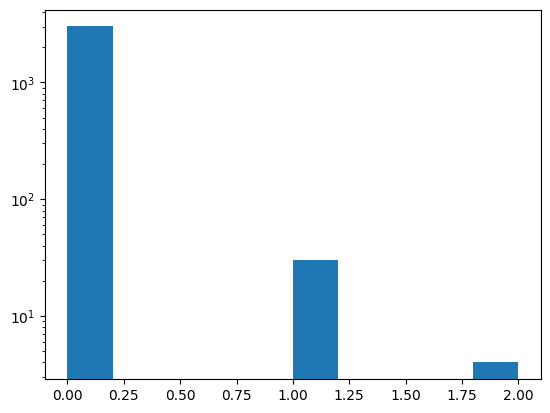

In [148]:
plt.hist(df_counts[0].toarray().flatten(), log=True);